# Activity 3: Exploratory Data Analysis (EDA)
### Emathrix Training Center

In Activity 2 you *collected* data. Now you *analyze* it, the real job of a data analyst.

We pick up the **tourism table** you scraped from `car_data.html`, then explore it: check its quality, summarize it, compare groups, look for relationships, and visualize the whole thing.

**Reminder:** this is **simulated sample data** for training. The numbers are realistic but invented, so any pattern or recommendation here is a demonstration of the *method*, not real advice about CAR tourism.

Run each cell with **Shift + Enter**, top to bottom.


## Step 1: Setup and load the scraped data

Upload **`car_data.html`** into Colab first (folder icon on the left, then upload). This cell re-scrapes the tourism table so this notebook works on its own.

In [ ]:
import urllib.request; urllib.request.urlretrieve('https://datasciencebaguio-production.up.railway.app/car_data', 'car_data.html'); print('Downloaded car_data.html')

Downloaded car_data.html


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Scrape the tourism table (3rd table in the file)
df = pd.read_html('car_data.html')[2]

print(f"Loaded {len(df)} tourism sites with {df.shape[1]} columns.")
print("Columns:", list(df.columns))
display(df.head())

Loaded 40 tourism sites with 9 columns.
Columns: ['Site ID', 'Site Name', 'Location', 'Province', 'Type', 'Annual_Visitors', 'Entry_Fee_PHP', 'Rating', 'Accessibility']


,Site ID,Site Name,Location,Province,Type,Annual_Visitors,Entry_Fee_PHP,Rating,Accessibility
0,TOU001,Kiangan Shrine,Kiangan,Ifugao,Religious,6367,0,3.9,Difficult
1,TOU002,Tabuk City Monument,Tabuk City,Kalinga,Historical,43607,0,4.6,Difficult
2,TOU003,Baguio City Museum,Baguio City,Benguet,Cultural,2335,150,3.3,Easy
3,TOU004,Hingyon Rice Terraces,Hingyon,Ifugao,Natural,15284,100,4.4,Moderate
4,TOU005,Dolores Heritage Village,Dolores,Abra,Cultural,8084,150,3.1,Moderate


## Step 2: Know your columns

A quick look at data types and a statistical summary of the numeric columns. Always do this before analyzing.

In [ ]:
print("Data types:")
print(df.dtypes)

print("\nSummary of numeric columns:")
display(df[['Annual_Visitors', 'Entry_Fee_PHP', 'Rating']].describe().round(2))

Data types:
Site ID             object
Site Name           object
Location            object
Province            object
Type                object
Annual_Visitors      int64
Entry_Fee_PHP        int64
Rating             float64
Accessibility       object
dtype: object

Summary of numeric columns:


,Annual_Visitors,Entry_Fee_PHP,Rating
count,40.00,40.00,40.00
mean,26071.02,52.50,4.00
std,14374.74,55.87,0.57
min,2335.00,0.00,3.10
25%,12427.00,0.00,3.50
50%,30152.00,35.00,3.90
75%,36684.25,100.00,4.43
max,47859.00,150.00,5.00


## Step 3: Data quality check

Real data is messy. Before trusting it, check for missing values and duplicate rows.

In [ ]:
missing = df.isnull().sum()
print("Missing values per column:")
if missing.sum() == 0:
    print("  None. Clean data.")
else:
    print(missing[missing > 0])

dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes == 0:
    print("  None.")

Missing values per column:
  None. Clean data.

Duplicate rows: 0
  None.


## Step 4: Count things (categorical breakdown)

How are the sites split across provinces and types? `value_counts` is your friend.

In [ ]:
print("Sites by Province:")
for prov, n in df['Province'].value_counts().items():
    print(f"  {prov}: {n} ({n/len(df)*100:.0f}%)")

print("\nSites by Type:")
for t, n in df['Type'].value_counts().items():
    print(f"  {t}: {n} ({n/len(df)*100:.0f}%)")

Sites by Province:
  Mountain Province: 9 (22%)
  Ifugao: 7 (18%)
  Kalinga: 7 (18%)
  Abra: 7 (18%)
  Benguet: 5 (12%)
  Apayao: 5 (12%)

Sites by Type:
  Cultural: 10 (25%)
  Historical: 9 (22%)
  Natural: 8 (20%)
  Adventure: 7 (18%)
  Religious: 6 (15%)


## Step 5: Key metrics

The headline numbers a manager would ask for.

In [ ]:
total_visitors = df['Annual_Visitors'].sum()
avg_visitors = df['Annual_Visitors'].mean()
avg_rating = df['Rating'].mean()
free_sites = (df['Entry_Fee_PHP'] == 0).sum()
paid_sites = (df['Entry_Fee_PHP'] > 0).sum()

print(f"Total annual visitors: {total_visitors:,}")
print(f"Average visitors per site: {avg_visitors:,.0f}")
print(f"Average rating: {avg_rating:.2f} out of 5")
print(f"Free-entry sites: {free_sites}  |  Paid sites: {paid_sites}")

Total annual visitors: 1,042,841
Average visitors per site: 26,071
Average rating: 4.00 out of 5
Free-entry sites: 15  |  Paid sites: 25


## Step 6: Compare groups

Grouping is the heart of analysis. Here we rank provinces and types by their numbers.

In [ ]:
print("PROVINCE PERFORMANCE (by total visitors):")
province_stats = df.groupby('Province').agg(
    Total_Visitors=('Annual_Visitors', 'sum'),
    Avg_Visitors=('Annual_Visitors', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Site_Count=('Site ID', 'count')
).round(1).sort_values('Total_Visitors', ascending=False)
display(province_stats)

print("\nTOURISM TYPE PERFORMANCE (by total visitors):")
type_stats = df.groupby('Type').agg(
    Total_Visitors=('Annual_Visitors', 'sum'),
    Avg_Visitors=('Annual_Visitors', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Fee=('Entry_Fee_PHP', 'mean')
).round(1).sort_values('Total_Visitors', ascending=False)
display(type_stats)

PROVINCE PERFORMANCE (by total visitors):


,Total_Visitors,Avg_Visitors,Avg_Rating,Site_Count
Province,,,,
Mountain Province,252447,28049.7,3.7,9
Kalinga,222120,31731.4,4.0,7
Ifugao,172911,24701.6,4.0,7
Abra,157445,22492.1,4.1,7
Apayao,147756,29551.2,4.5,5
Benguet,90162,18032.4,3.8,5



TOURISM TYPE PERFORMANCE (by total visitors):


,Total_Visitors,Avg_Visitors,Avg_Rating,Avg_Fee
Type,,,,
Adventure,255687,36526.7,3.8,45.7
Historical,253016,28112.9,3.9,52.2
Natural,232111,29013.9,4.1,55.0
Cultural,171592,17159.2,4.0,87.0
Religious,130435,21739.2,4.1,0.0


## Step 7: Top and bottom performers

Which sites pull the most visitors, and which lag behind?

In [ ]:
print("TOP 5 MOST VISITED:")
top = df.nlargest(5, 'Annual_Visitors')[['Site Name', 'Province', 'Annual_Visitors', 'Rating']]
display(top)

print("BOTTOM 5 (fewest visitors):")
bottom = df.nsmallest(5, 'Annual_Visitors')[['Site Name', 'Province', 'Annual_Visitors', 'Rating']]
display(bottom)

TOP 5 MOST VISITED:


,Site Name,Province,Annual_Visitors,Rating
5,Rizal Shrine,Kalinga,47859,3.4
18,Sadanga War Memorial,Mountain Province,47062,3.5
6,Tadian Museum,Mountain Province,46691,4.7
15,Lamut Zipline,Ifugao,46259,4.3
25,Lagawe Camping Site,Ifugao,45987,3.3


BOTTOM 5 (fewest visitors):


,Site Name,Province,Annual_Visitors,Rating
2,Baguio City Museum,Benguet,2335,3.3
22,Kabayan Heritage Village,Benguet,3982,4.1
33,Santa Marcela Museum,Apayao,4908,4.6
29,Bauko Ancestral House,Mountain Province,6320,3.5
0,Kiangan Shrine,Ifugao,6367,3.9


## Step 8: Correlation, do numbers move together?

Correlation ranges from -1 to +1. Near 0 means no relationship.

**Read this carefully:** because the data is randomly generated, these correlations will be near zero and mean nothing. That is itself a useful lesson, on real data this is how you'd check whether, say, higher ratings go with more visitors.

Correlation matrix:


,Annual_Visitors,Entry_Fee_PHP,Rating
Annual_Visitors,1.000,-0.087,0.048
Entry_Fee_PHP,-0.087,1.000,-0.173
Rating,0.048,-0.173,1.000


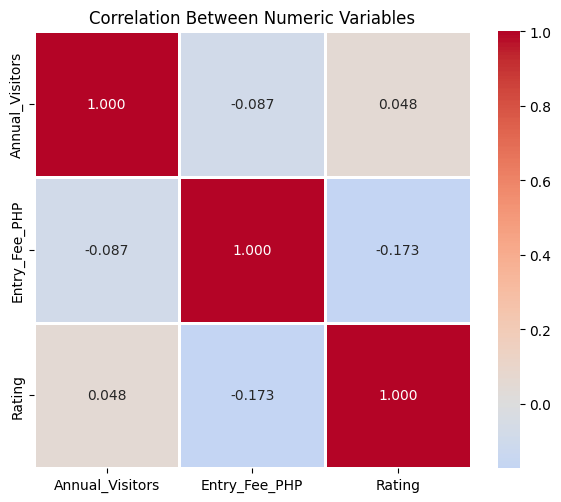

In [ ]:
corr = df[['Annual_Visitors', 'Entry_Fee_PHP', 'Rating']].corr()
print("Correlation matrix:")
display(corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=1)
plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

## Step 9: The visual dashboard

Six clean charts summarizing the whole dataset.

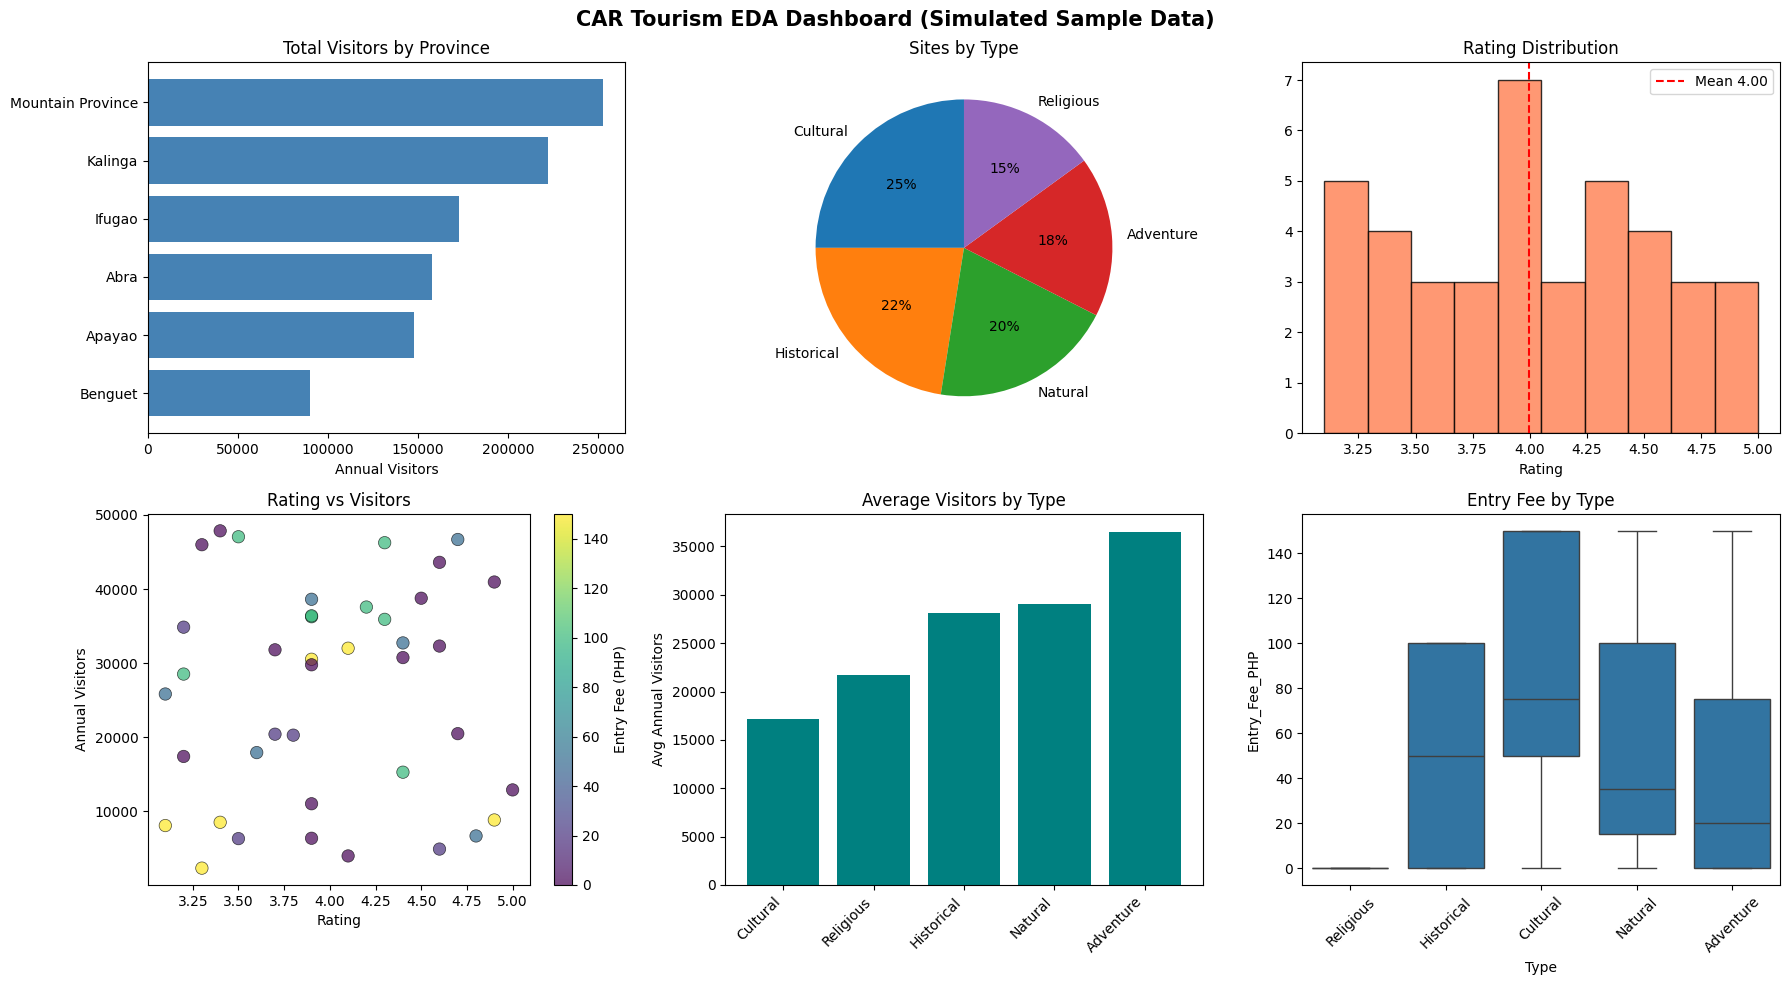

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CAR Tourism EDA Dashboard (Simulated Sample Data)', fontsize=15, fontweight='bold')

# 1. Total visitors by province
pv = df.groupby('Province')['Annual_Visitors'].sum().sort_values()
axes[0, 0].barh(pv.index, pv.values, color='steelblue')
axes[0, 0].set_title('Total Visitors by Province')
axes[0, 0].set_xlabel('Annual Visitors')

# 2. Site type distribution
td = df['Type'].value_counts()
axes[0, 1].pie(td.values, labels=td.index, autopct='%1.0f%%', startangle=90)
axes[0, 1].set_title('Sites by Type')

# 3. Rating distribution
axes[0, 2].hist(df['Rating'], bins=10, color='coral', edgecolor='black', alpha=0.8)
axes[0, 2].axvline(df['Rating'].mean(), color='red', linestyle='--',
                   label=f"Mean {df['Rating'].mean():.2f}")
axes[0, 2].set_title('Rating Distribution')
axes[0, 2].set_xlabel('Rating')
axes[0, 2].legend()

# 4. Rating vs visitors, colored by fee
sc = axes[1, 0].scatter(df['Rating'], df['Annual_Visitors'],
                        c=df['Entry_Fee_PHP'], cmap='viridis',
                        alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[1, 0].set_title('Rating vs Visitors')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Annual Visitors')
fig.colorbar(sc, ax=axes[1, 0], label='Entry Fee (PHP)')

# 5. Average visitors by type
avt = df.groupby('Type')['Annual_Visitors'].mean().sort_values()
axes[1, 1].bar(range(len(avt)), avt.values, color='teal')
axes[1, 1].set_xticks(range(len(avt)))
axes[1, 1].set_xticklabels(avt.index, rotation=45, ha='right')
axes[1, 1].set_title('Average Visitors by Type')
axes[1, 1].set_ylabel('Avg Annual Visitors')

# 6. Entry fee by type (boxplot, seaborn handles the axis cleanly)
sns.boxplot(data=df, x='Type', y='Entry_Fee_PHP', ax=axes[1, 2])
axes[1, 2].set_title('Entry Fee by Type')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 10: Turning analysis into findings

Good analysts don't just make charts, they say what the numbers mean. Below we compute findings straight from the data.

**Big caveat, say this out loud:** the data is simulated, so these "findings" and "recommendations" are a demonstration of *how* analysis leads to decisions. They are **not** real advice about CAR tourism. On real data, this same code would produce real insight.

In [ ]:
top_prov = province_stats.index[0]
low_prov = province_stats.index[-1]
gap = province_stats.loc[top_prov, 'Total_Visitors'] / province_stats.loc[low_prov, 'Total_Visitors']

best_type = type_stats.index[0]
free_avg = df[df['Entry_Fee_PHP'] == 0]['Annual_Visitors'].mean()
paid_avg = df[df['Entry_Fee_PHP'] > 0]['Annual_Visitors'].mean()

print("FINDINGS (from the simulated data):")
print(f"1. {top_prov} leads in total visitors; {low_prov} is lowest. Gap is about {gap:.1f}x.")
print(f"2. '{best_type}' sites draw the most visitors overall.")
print(f"3. Free sites average {free_avg:,.0f} visitors; paid sites average {paid_avg:,.0f}.")
print(f"4. Average rating across all sites is {df['Rating'].mean():.2f} out of 5.")

print("\nHOW THIS WOULD DRIVE DECISIONS (illustrative only):")
print("- A real analyst would ask why the lowest province lags, then check infrastructure or access.")
print("- They'd promote high-rated but low-traffic sites.")
print("- They'd test whether entry fees actually affect visits, here the data is random, so we can't.")

print("\nThe skill you practiced: load, check, summarize, group, correlate, visualize, interpret.")

FINDINGS (from the simulated data):
1. Mountain Province leads in total visitors; Benguet is lowest. Gap is about 2.8x.
2. 'Adventure' sites draw the most visitors overall.
3. Free sites average 27,599 visitors; paid sites average 25,155.
4. Average rating across all sites is 4.00 out of 5.

HOW THIS WOULD DRIVE DECISIONS (illustrative only):
- A real analyst would ask why the lowest province lags, then check infrastructure or access.
- They'd promote high-rated but low-traffic sites.
- They'd test whether entry fees actually affect visits, here the data is random, so we can't.

The skill you practiced: load, check, summarize, group, correlate, visualize, interpret.


---
### What you learned

You took scraped data and ran a full **exploratory data analysis**: quality checks, summaries, group comparisons, correlation, visualization, and interpretation. This is the core daily work of a data analyst.

The one habit to carry forward: always know whether your data is real or simulated, and never let a chart make you forget which one you're looking at.

— Emathrix Training Center